# ASL Sensor Dataglove -- Data Exploration

**Project:** ASL Text-to-Speech Gloves  
**Dataset:** figshare ASL-Sensor-Dataglove-Dataset (25 subjects, 40 signs, ~100Hz)  
**Goal:** Understand data structure, signal characteristics, class balance, and subject-level variation before building the PyTorch model.

---

### How to run
1. From repo root: `docker compose build` (first time only, or after dependency changes)
2. From repo root: `docker compose up -d`
3. Open `localhost:8888` in your browser or connect via VS Code/Cursor Jupyter extension
4. Dataset is pre-mounted at `../data` -- no configuration needed
5. To stop: `docker compose down`

### Sections
1. Setup & dataset loading
2. Structure overview
3. Signal visualization
4. Class balance
5. Subject-level variation
6. Static vs. dynamic signs
7. Feature statistics & correlation
8. Windowing strategy preview
9. Key findings summary

## 1. Setup & Dataset Loading

Loads all 1,000 CSVs (25 subjects × 40 signs) into a single DataFrame. Each row is tagged with its subject, sign name, and sign type. Expect the output to confirm **1,000 files**, **~1.5M rows**, **25 subjects**, and **40 signs** -- anything less means some files failed to load.

In [1]:
# import necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from pathlib import Path

# set the figure size and font size
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# set the dataset root
DATASET_ROOT = Path('../data')

# 24 static signs (finger pose only, no wrist motion)
STATIC_SIGNS  = list('abcdefghiklmnopqrstuvwxy')

# 16 dynamic signs (require wrist/hand motion to perform)
DYNAMIC_SIGNS = ['j', 'z', 'bad', 'deaf', 'fine', 'good', 'goodbye',
                 'hello', 'hungry', 'me', 'no', 'please',
                 'sorry', 'thank you', 'yes', 'you']
ALL_SIGNS = STATIC_SIGNS + DYNAMIC_SIGNS

# set the metadata columns, don't need these for model
META_COLS    = ['timestamp', 'user_id']

# set the flex columns, 1 per finger to measure bend angle
FLEX_COLS    = ['flex_1', 'flex_2', 'flex_3', 'flex_4', 'flex_5']

# set the quaternion columns, wrist orientation in 3D space
QUAT_COLS    = ['Qw', 'Qx', 'Qy', 'Qz']

# set the gyroscope columns, wrist rotation rate (angular velocity)
GYRO_COLS    = ['GYRx', 'GYRy', 'GYRz']

# set the accelerometer columns relative to the sensor
ACC_B_COLS   = ['ACCx_body', 'ACCy_body', 'ACCz_body']

# set the accelerometer columns relative to the ground
ACC_W_COLS   = ['ACCx_world', 'ACCy_world', 'ACCz_world']

# set the raw accelerometer columns
ACC_R_COLS   = ['ACCx', 'ACCy', 'ACCz']

# all 21 sensor channels combined for full input vector per timestep
FEATURE_COLS = FLEX_COLS + QUAT_COLS + GYRO_COLS + ACC_B_COLS + ACC_W_COLS + ACC_R_COLS

# verify operations are working
print(f'Dataset root exists: {DATASET_ROOT.exists()}')
print(f'Static: {len(STATIC_SIGNS)} | Dynamic: {len(DYNAMIC_SIGNS)} | Total: {len(ALL_SIGNS)} signs')
print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Dataset root exists: True
Static: 24 | Dynamic: 16 | Total: 40 signs
Feature columns (21): ['flex_1', 'flex_2', 'flex_3', 'flex_4', 'flex_5', 'Qw', 'Qx', 'Qy', 'Qz', 'GYRx', 'GYRy', 'GYRz', 'ACCx_body', 'ACCy_body', 'ACCz_body', 'ACCx_world', 'ACCy_world', 'ACCz_world', 'ACCx', 'ACCy', 'ACCz']


In [2]:
# load all sign CSVs into a single DataFrame
def load_dataset(root: Path) -> pd.DataFrame:
    frames = []

    # iterate over all subject directories
    for subject_dir in sorted(d for d in root.iterdir() if d.is_dir()):
        subject_id = subject_dir.name

        # iterate over all CSV files in the subject directory
        for csv_file in sorted(subject_dir.glob('*.csv')):
            sign = csv_file.stem

            # skip corrupted files, tag each row with subject, sign name, and sign type
            try:
                df = pd.read_csv(csv_file)
                df['subject']   = subject_id
                df['sign']      = sign
                df['sign_type'] = 'dynamic' if sign in DYNAMIC_SIGNS else 'static'
                frames.append(df)
            except Exception as e:
                print(f'Failed: {csv_file}: {e}')

    # concatenate all frames into a single DataFrame
    full = pd.concat(frames, ignore_index=True)
    print(f'Loaded {len(frames)} files | {full.shape[0]:,} rows | '
          f'{full["subject"].nunique()} subjects | {full["sign"].nunique()} signs')
    return full

# load the full dataset
df = load_dataset(DATASET_ROOT)

Loaded 1000 files | 1,500,000 rows | 25 subjects | 40 signs


## 2. Structure Overview

Confirms the dataset loaded correctly. Shape should be (~1.5M rows, 24 columns). All feature columns should report no missing values, every subject/sign pair should have exactly 1,500 rows, and sample rate should be close to 100Hz.

In [3]:
# print the shape and column types to verify the dataset loaded correctly
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)

# preview the first 3 rows of the dataset
df.head(3)

Shape: (1500000, 26)

Dtypes:
timestamp     float64
user_id         int64
flex_1        float64
flex_2        float64
flex_3        float64
flex_4        float64
flex_5        float64
Qw            float64
Qx            float64
Qy            float64
Qz            float64
GYRx          float64
GYRy          float64
GYRz          float64
ACCx          float64
ACCy          float64
ACCz          float64
ACCx_body     float64
ACCy_body     float64
ACCz_body     float64
ACCx_world    float64
ACCy_world    float64
ACCz_world    float64
subject           str
sign              str
sign_type         str
dtype: object


,timestamp,user_id,flex_1,flex_2,flex_3,flex_4,flex_5,Qw,Qx,Qy,...,ACCz,ACCx_body,ACCy_body,ACCz_body,ACCx_world,ACCy_world,ACCz_world,subject,sign,sign_type
0,1.616133e+09,1,20.0,58.0,72.0,77.0,58.0,0.773499,0.087097,-0.627747,...,1.770508,-0.205762,0.082544,-0.155518,0.098096,0.124414,-0.218921,001,a,static
1,1.616133e+09,1,20.0,58.0,70.0,76.0,58.0,0.773438,0.086060,-0.627991,...,1.762134,-0.232080,0.086133,-0.162695,0.099292,0.130396,-0.245239,001,a,static
2,1.616133e+09,1,20.0,58.0,73.0,75.0,60.0,0.773376,0.084900,-0.628235,...,1.754956,-0.222510,0.066992,-0.167480,0.107666,0.111255,-0.239258,001,a,static


Three sanity checks in one cell -- missing values, row count consistency, and sample rate. All three should pass cleanly before trusting any downstream analysis.

In [4]:
# check for missing values across all feature columns
print('Missing values:')
missing = df[FEATURE_COLS].isnull().sum()
print(missing[missing > 0] if missing.any() else 'None -- dataset is complete')

# verify row count is consistent across all subject/sign combinations (expect 1500 each)
rows = df.groupby(['subject', 'sign']).size()
print(f'\nRows per file -- Min: {rows.min()} | Max: {rows.max()} | Mean: {rows.mean():.1f}')

# estimate sample rate from timestamp deltas on a single recording
rec = df[(df['subject'] == '001') & (df['sign'] == 'a')].sort_values('timestamp')
dt  = rec['timestamp'].diff().dropna() # diff() gives time between consecutive rows
print(f'\nEstimated sample rate: {1/dt.mean():.1f} Hz')
print(f'Recording duration:    {rec["timestamp"].iloc[-1] - rec["timestamp"].iloc[0]:.2f} s')

Missing values:
None -- dataset is complete

Rows per file -- Min: 1500 | Max: 1500 | Mean: 1500.0

Estimated sample rate: 43.5 Hz
Recording duration:    34.48 s


## 3. Signal Visualization

Look at the gyroscope row -- sign `a` should show near-flat traces while sign `j` should show clear movement spikes. This is the visual proof that static and dynamic signs are distinguishable from gyroscope data alone.

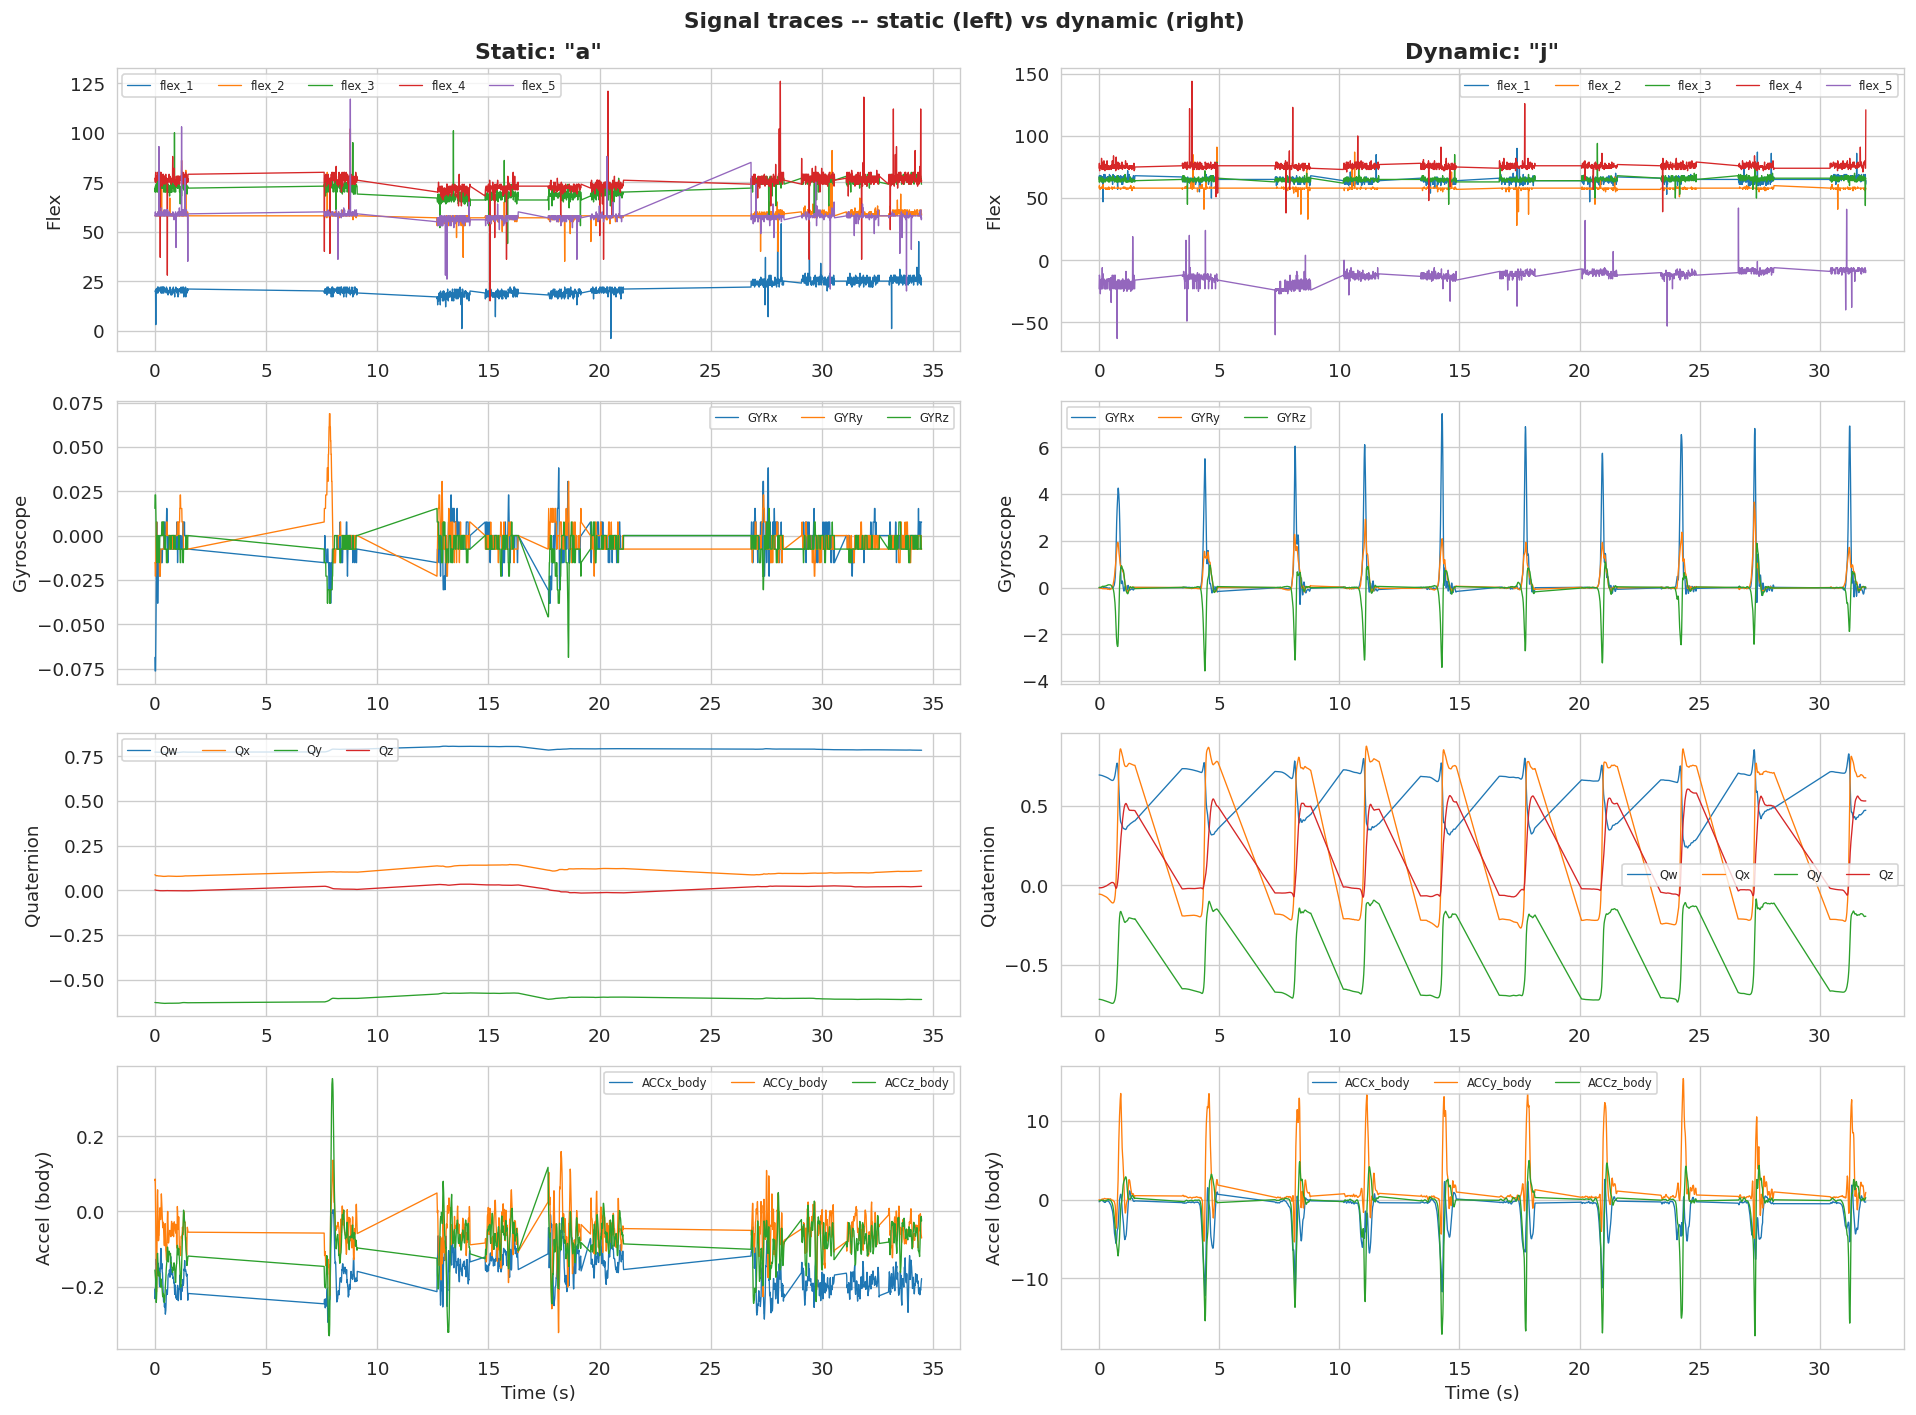

In [5]:
# plot flex, gyroscope, quaternion, and body acceleration traces side by side
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
fig.suptitle('Signal traces -- static (left) vs dynamic (right)', fontsize=13, fontweight='bold')

# iterate over both signs -- col=0 for 'a' (left column), col=1 for 'j' (right column)
for col, (sign, label) in enumerate([('a', 'Static: "a"'), ('j', 'Dynamic: "j"')]):
    # filter to subject 001's recording for this sign, reset time to start at 0
    rec = df[(df['subject'] == '001') & (df['sign'] == sign)].sort_values('timestamp').reset_index(drop=True)
    t   = rec['timestamp'] - rec['timestamp'].iloc[0]
    axes[0, col].set_title(label, fontweight='bold')

    # plot each sensor group into its own row
    for ch in FLEX_COLS:  axes[0, col].plot(t, rec[ch], lw=0.8, label=ch)
    for ch in GYRO_COLS:  axes[1, col].plot(t, rec[ch], lw=0.8, label=ch)
    for ch in QUAT_COLS:  axes[2, col].plot(t, rec[ch], lw=0.8, label=ch)
    for ch in ACC_B_COLS: axes[3, col].plot(t, rec[ch], lw=0.8, label=ch)

    # label y-axes and add legends for each row
    for i, ylabel in enumerate(['Flex', 'Gyroscope', 'Quaternion', 'Accel (body)']):
        axes[i, col].set_ylabel(ylabel)
        axes[i, col].legend(fontsize=7, ncol=5)
    axes[3, col].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

Signs with overlapping lines have similar flex profiles and will be the hardest for the model to distinguish. Look for signs that cluster tightly together -- those are the ones most likely to be confused during classification.

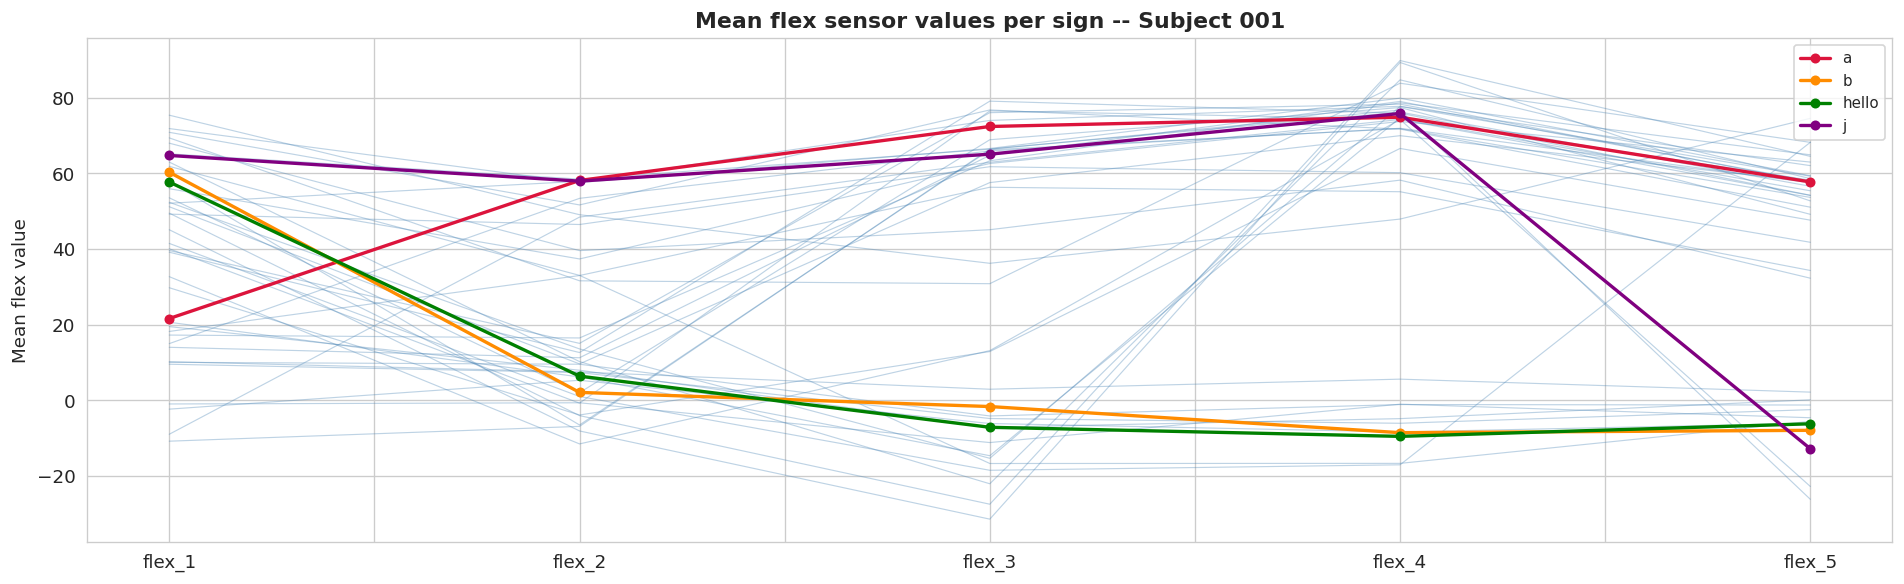

In [6]:
# plot mean flex sensor values per sign for subject 001
sub  = df[df['subject'] == '001'].groupby('sign')[FLEX_COLS].mean()
fig, ax = plt.subplots(figsize=(16, 5))

# all 40 signs in faint blue, then overlay a few highlighted signs for reference
sub.T.plot(ax=ax, legend=False, lw=0.7, color='steelblue', alpha=0.35)
for sign, color in [('a','crimson'),('b','darkorange'),('hello','green'),('j','purple')]:
    if sign in sub.index:
        ax.plot(FLEX_COLS, sub.loc[sign], color=color, lw=2, label=sign, marker='o', ms=5)
ax.set_title('Mean flex sensor values per sign -- Subject 001', fontweight='bold')
ax.set_ylabel('Mean flex value')
handles = [plt.Line2D([0], [0], color=c, lw=2, marker='o', ms=5, label=s)
           for s, c in [('a','crimson'),('b','darkorange'),('hello','green'),('j','purple')]]
ax.legend(handles=handles, fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

## 4. Class Balance

Every bar should reach the dashed line at 25. Any sign falling short means some subjects are missing that recording -- this would create class imbalance during training and needs to be accounted for.

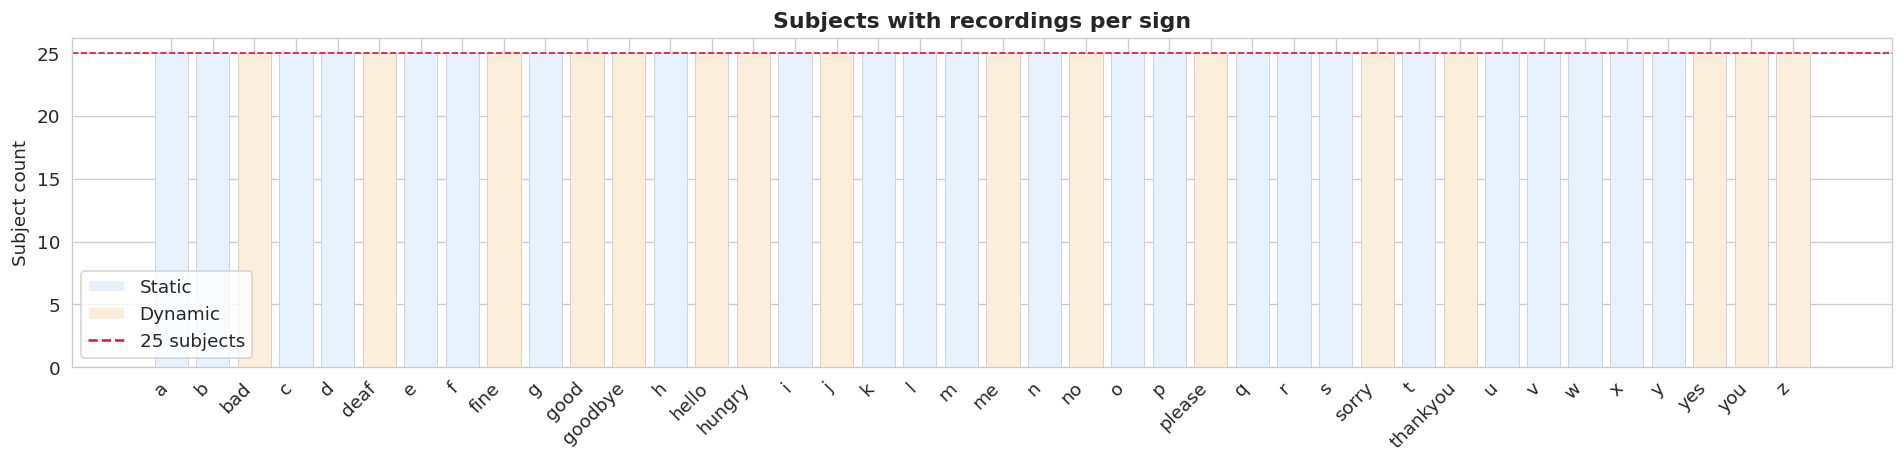

Min: 25 (a) | Max: 25 (a)


In [7]:
# count how many subjects have a recording for each sign

# count unique subjects per sign, sorted descending
rps    = df.groupby('sign')['subject'].nunique().sort_values(ascending=False)

# color bars by sign type -- blue for static, orange for dynamic
colors = ['#E6F1FB' if s in STATIC_SIGNS else '#FAEEDA' for s in rps.index]


fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(rps.index, rps.values, color=colors, edgecolor='#ccc', lw=0.5)

# dashed line at 25 -- the expected maximum
ax.axhline(25, color='crimson', ls='--', lw=1)
ax.set_title('Subjects with recordings per sign', fontweight='bold')
ax.set_ylabel('Subject count')
ax.legend(handles=[
    Patch(facecolor='#E6F1FB', label='Static'),
    Patch(facecolor='#FAEEDA', label='Dynamic'),
    plt.Line2D([0],[0], color='crimson', ls='--', label='25 subjects')
])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# print any signs that are missing recordings from some subjects
print(f'Min: {rps.min()} ({rps.idxmin()}) | Max: {rps.max()} ({rps.idxmax()})')

## 5. Subject-Level Variation

Each faint blue line is one subject signing `a`. Wide spread between lines means people sign the same letter very differently -- per-subject normalization is critical before training. Tight clustering means the raw data is already consistent.

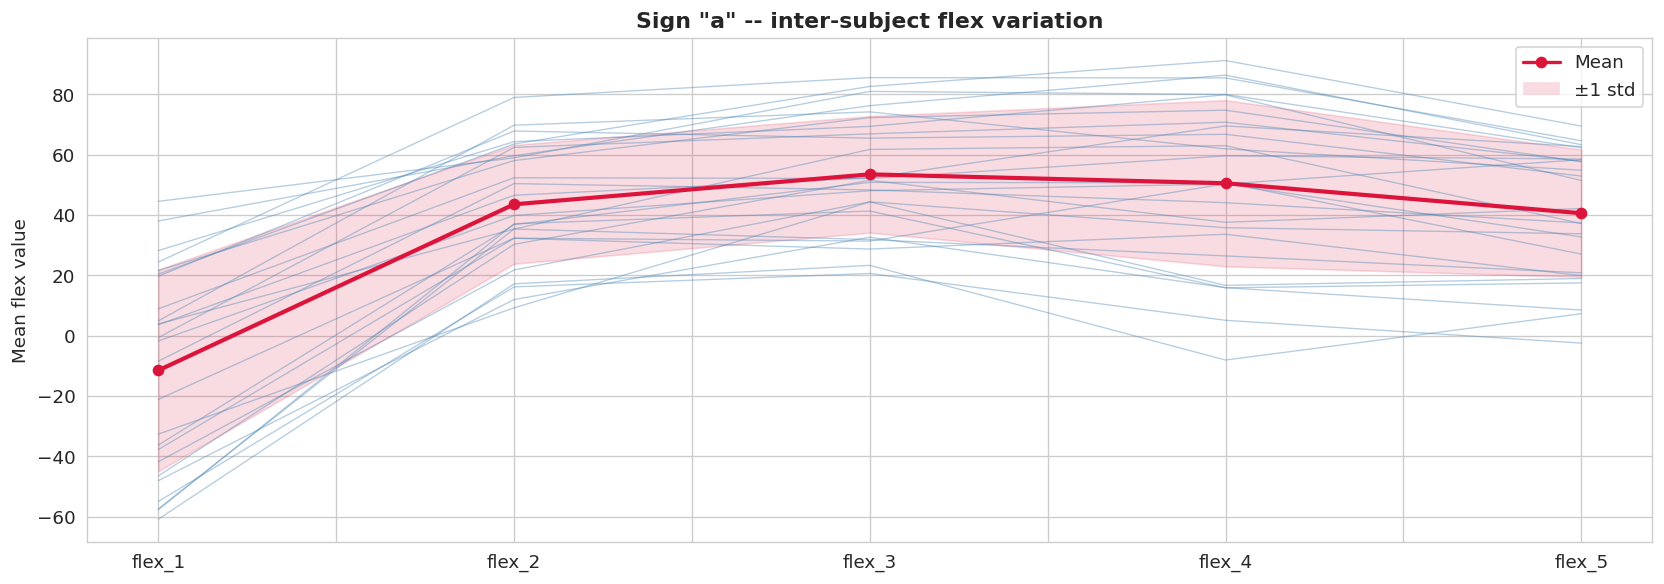

In [8]:
# plot mean flex values for sign 'a' across all 25 subjects
sign_data = df[df['sign'] == 'a'].groupby('subject')[FLEX_COLS].mean()

fig, ax = plt.subplots(figsize=(14, 5))

# each faint blue line is one subject
sign_data.T.plot(ax=ax, legend=False, lw=0.8, alpha=0.4, color='steelblue')

# red line is the mean across all subjects, shaded band is ±1 standard deviation
ax.plot(FLEX_COLS, sign_data.mean(), color='crimson', lw=2.5, label='Mean', marker='o')
ax.fill_between(FLEX_COLS,
    sign_data.mean() - sign_data.std(),
    sign_data.mean() + sign_data.std(),
    alpha=0.15, color='crimson', label='±1 std')
ax.set_title('Sign "a" -- inter-subject flex variation', fontweight='bold')
ax.set_ylabel('Mean flex value')
ax.legend(handles=[
    plt.Line2D([0], [0], color='crimson', lw=2, marker='o', label='Mean'),
    plt.matplotlib.patches.Patch(facecolor='crimson', alpha=0.15, label='±1 std')
])
plt.tight_layout()
plt.show()

Features with high CoV vary significantly across subjects and need aggressive normalization. Features with low CoV are naturally consistent. Flex channels typically have the highest CoV -- expect them to dominate the top of the chart.

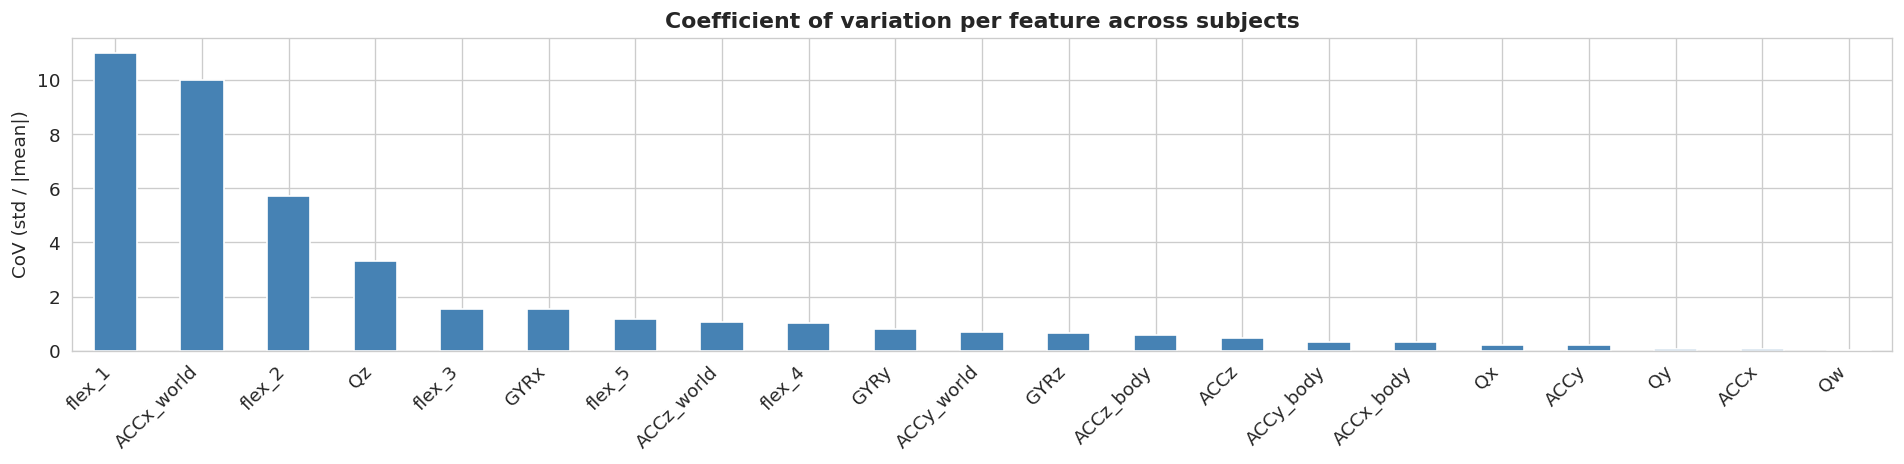

Top 5 highest variance (hardest to normalize): ['flex_1', 'ACCx_world', 'flex_2', 'Qz', 'flex_3']
Top 5 lowest variance (most consistent):       ['Qx', 'ACCy', 'Qy', 'ACCx', 'Qw']


In [9]:
# coefficient of variation (CoV) = std / mean -- measures how much each feature varies across subjects
cv = (df.groupby('subject')[FEATURE_COLS].mean().std() /
      df.groupby('subject')[FEATURE_COLS].mean().mean().abs()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(16, 4))
cv.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Coefficient of variation per feature across subjects', fontweight='bold')
ax.set_ylabel('CoV (std / |mean|)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# high CoV means the feature reads differently per person and needs aggressive normalization
print('Top 5 highest variance (hardest to normalize):', cv.head().index.tolist())

# low CoV means the feature is consistent and reliable across signers
print('Top 5 lowest variance (most consistent):      ', cv.tail().index.tolist())

## 6. Static vs. Dynamic Signs

The two distributions on the left should show clear separation -- dynamic signs cluster at higher gyroscope magnitudes than static ones. Heavy overlap would undermine the two-model strategy. The bar chart on the right should show dynamic signs dominating the top.

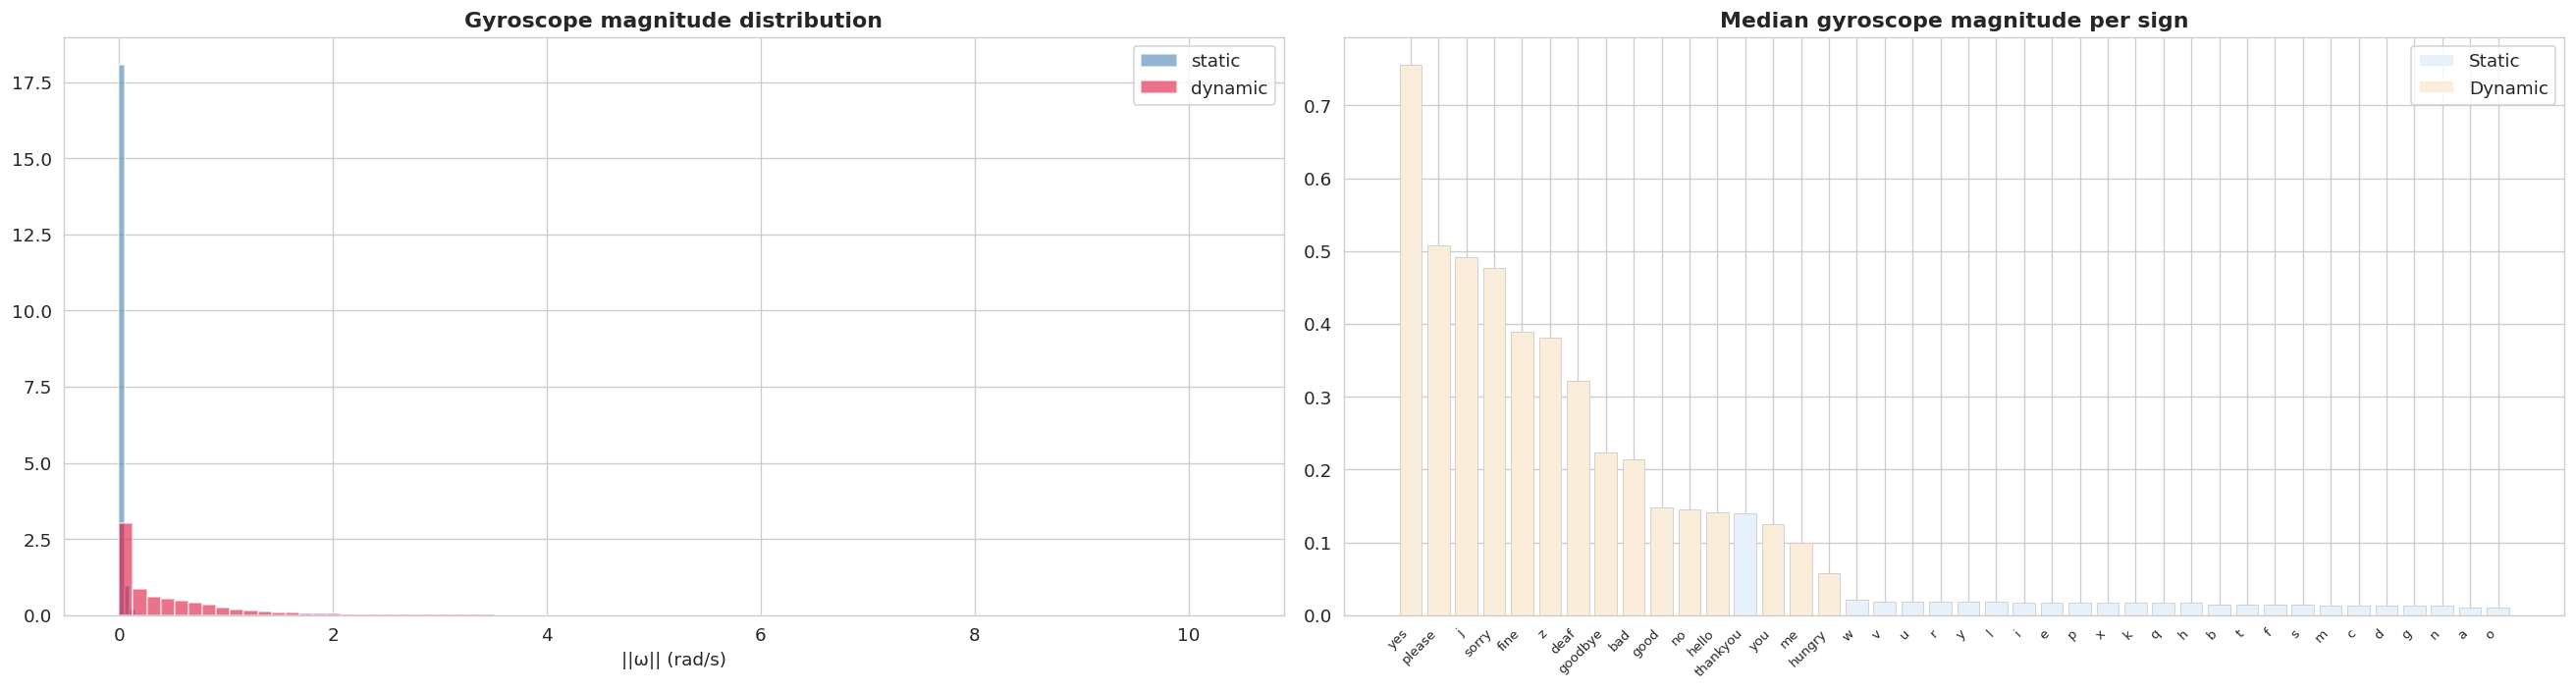

In [10]:
# compute gyroscope magnitude -- single value summarizing total rotational energy at each timestep

df['gyro_mag'] = np.sqrt(df['GYRx']**2 + df['GYRy']**2 + df['GYRz']**2)

fig, axes = plt.subplots(1, 2, figsize=(22, 6))
plt.subplots_adjust(bottom=0.25)

# left plot: overlapping distributions -- clear separation confirms gyro is a strong static/dynamic separator
for st, color in [('static','steelblue'), ('dynamic','crimson')]:
    axes[0].hist(df[df['sign_type']==st]['gyro_mag'], bins=80, alpha=0.6, color=color, label=st, density=True)
axes[0].set_title('Gyroscope magnitude distribution', fontweight='bold')
axes[0].set_xlabel('||ω|| (rad/s)')
axes[0].legend()

# right plot: median gyro magnitude per sign, sorted descending
gyro_by_sign = df.groupby(['sign','sign_type'])['gyro_mag'].median().reset_index().sort_values('gyro_mag', ascending=False)
colors2 = ['#FAEEDA' if t == 'dynamic' else '#E6F1FB' for t in gyro_by_sign['sign_type']]
axes[1].bar(gyro_by_sign['sign'], gyro_by_sign['gyro_mag'], color=colors2, edgecolor='#ccc', lw=0.5)
axes[1].set_title('Median gyroscope magnitude per sign', fontweight='bold')
plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[1].legend(handles=[Patch(facecolor='#E6F1FB',label='Static'), Patch(facecolor='#FAEEDA',label='Dynamic')])
plt.tight_layout()
plt.show()

## 7. Feature Statistics & Correlation

Look for features with wildly different ranges -- a flex sensor ranging 0–100 and a gyroscope ranging -2000–2000 fed raw into a model will cause the gyroscope to dominate purely due to scale. This table tells us how aggressive normalization needs to be.

In [11]:
# print summary statistics for all 21 feature channels
stats = df[FEATURE_COLS].describe().T[['mean','std','min','max']]
stats['range'] = stats['max'] - stats['min']
print(stats.round(3).to_string())

              mean     std      min      max     range
flex_1       2.629  42.388 -520.000  836.000  1356.000
flex_2      -3.824  34.505 -180.000  122.000   302.000
flex_3      11.971  48.322 -198.000  188.000   386.000
flex_4      24.895  48.349 -199.000  203.000   402.000
flex_5      17.155  37.974 -263.000  209.000   472.000
Qw           0.732   0.161   -0.220    1.000     1.220
Qx           0.174   0.247   -0.599    0.996     1.594
Qy          -0.484   0.296   -0.986    0.697     1.683
Qz          -0.008   0.160   -0.984    0.946     1.930
GYRx         0.009   0.318   -9.985    7.443    17.427
GYRy         0.009   0.442   -6.802    9.893    16.695
GYRz        -0.016   0.260   -5.153    4.015     9.168
ACCx_body   -0.381   1.510  -23.876   13.329    37.205
ACCy_body    0.155   1.732  -18.571   17.018    35.590
ACCz_body   -0.116   1.619  -28.004   18.349    46.353
ACCx_world  -0.004   1.541  -19.066   22.704    41.771
ACCy_world  -0.054   1.486  -21.760   23.734    45.495
ACCz_world

Dark red or dark blue squares indicate highly correlated feature pairs -- they carry redundant information. Any pairs flagged above 0.95 at the bottom are candidates for dropping before training. Expect the three accelerometer groups (body, world, raw) to correlate heavily with each other.

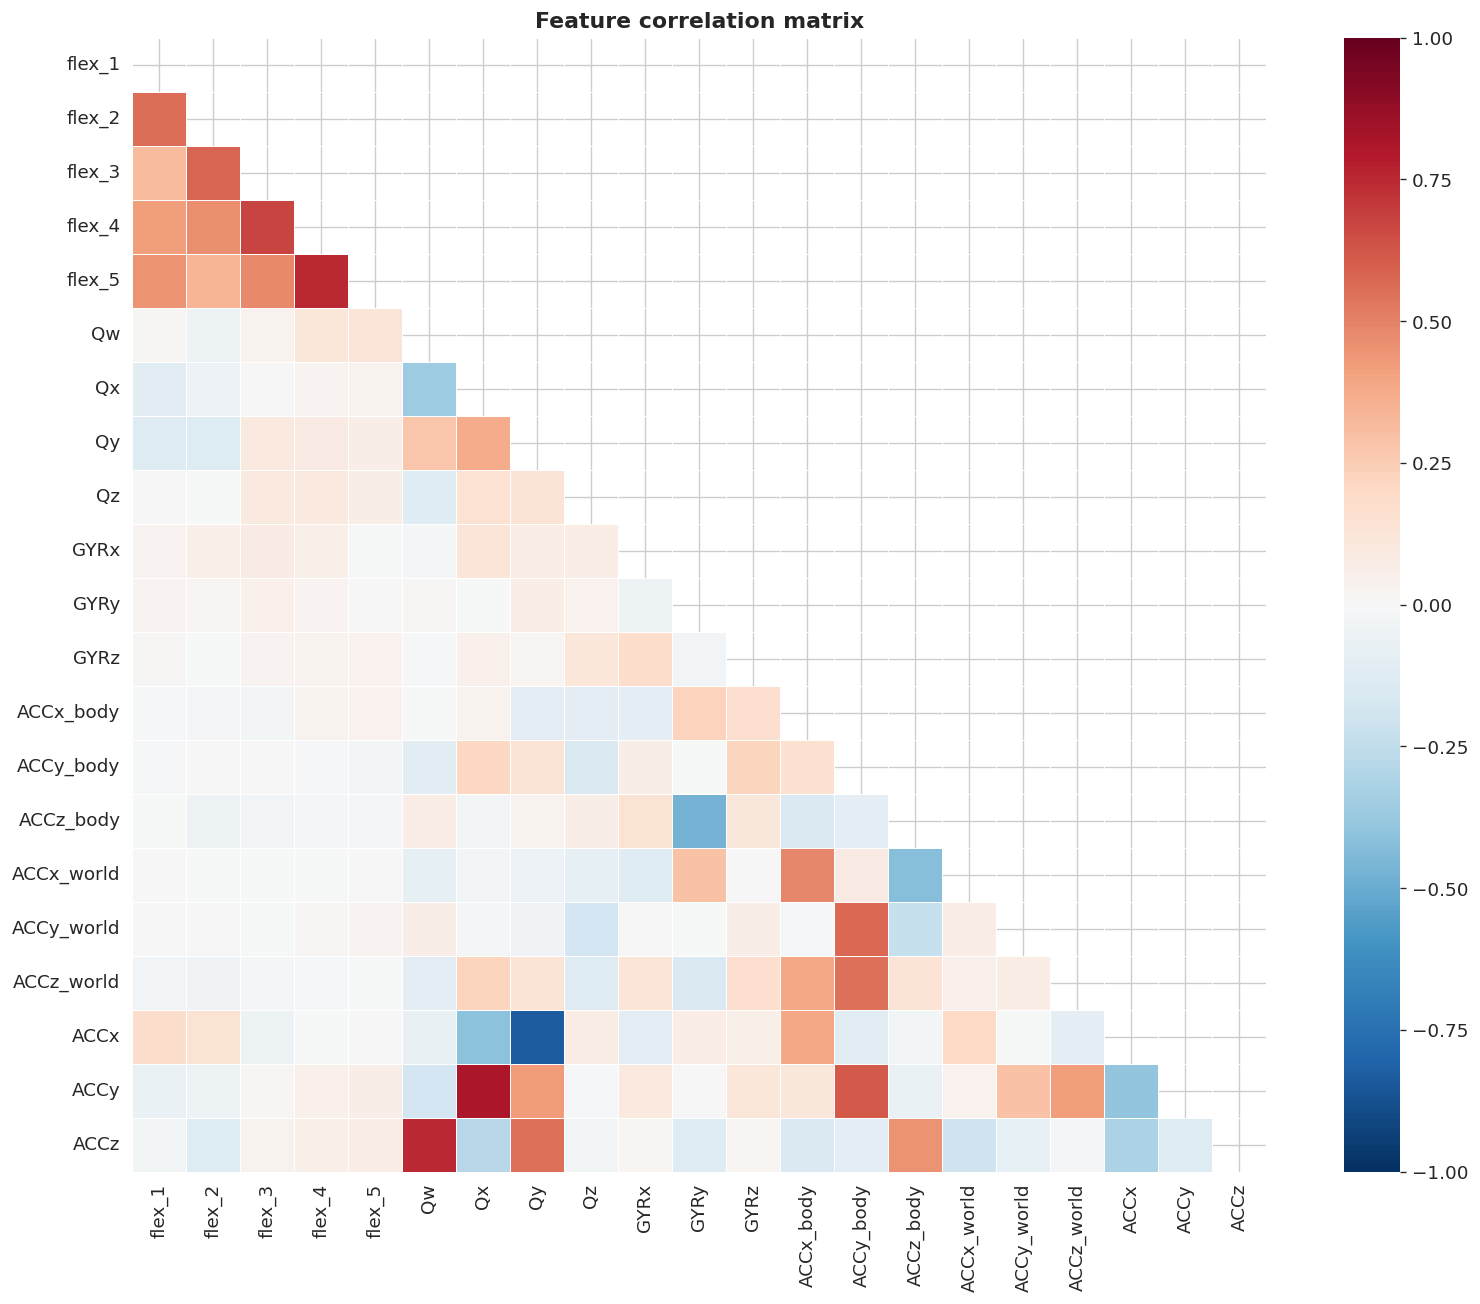

No pairs with |r| > 0.95


In [12]:
# sample 50k rows for performance -- correlation on 1.5M rows is slow
sample_df = df[FEATURE_COLS].sample(n=min(50000, len(df)), random_state=42)
corr = sample_df.corr()

# lower triangle only -- upper triangle masked to avoid duplicate pairs
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.3)
ax.set_title('Feature correlation matrix', fontweight='bold')
plt.tight_layout()
plt.show()

# flag pairs with |r| > 0.95 -- highly correlated features add noise without new information
upper    = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [(c, r, upper.loc[r,c]) for c in upper.columns for r in upper.index
             if pd.notna(upper.loc[r,c]) and upper.loc[r,c] > 0.95]
if high_corr:
    print('Pairs with |r| > 0.95:')
    for a, b, v in sorted(high_corr, key=lambda x: -x[2]):
        print(f'  {a:20s} <-> {b:20s}  r={v:.3f}')
else:
    print('No pairs with |r| > 0.95')

## 8. Windowing Strategy Preview

Larger windows capture more context but produce fewer training samples. Smaller windows give more samples but may miss slower dynamic signs. 100 timesteps (~1s) at 50% overlap is the recommended balance -- ~29,000 total samples across the full dataset.

In [13]:
# compare different window sizes and strides to determine how many training samples we get
# window = how many timesteps per sample, stride = how many timesteps to skip between windows
# 50% overlap (stride = window/2) doubles sample count vs no overlap
ROWS, N_SUBJ, N_SIGNS = 1500, 25, 40

print(f'{"Window":>8}  {"Stride":>8}  {"Windows/rec":>12}  {"Total samples":>15}')
for ws, st in [(50,25),(100,50),(100,25),(150,75),(200,100)]:
    # formula: how many windows of size ws fit into ROWS with step size st
    w     = max(0, (ROWS - ws) // st + 1)
    total = w * N_SUBJ * N_SIGNS
    tag   = ' <- recommended' if (ws,st)==(100,50) else ''
    print(f'{ws:>8}  {st:>8}  {w:>12}  {total:>15,}{tag}')

  Window    Stride   Windows/rec    Total samples
      50        25            59           59,000
     100        50            29           29,000 <- recommended
     100        25            57           57,000
     150        75            19           19,000
     200       100            14           14,000


Each shaded region is one training sample. Overlapping windows mean consecutive samples share 50 timesteps -- this is intentional and increases sample count without losing temporal context.

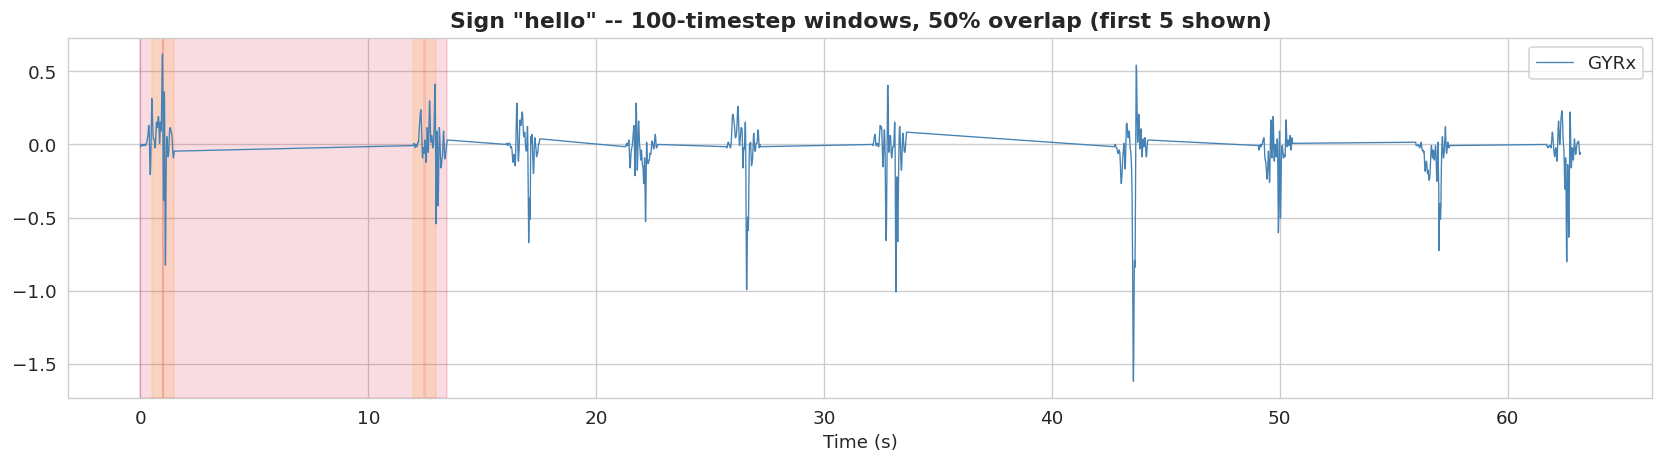

Total windows for this recording: 29


In [14]:
# visualize what a 100-timestep window actually looks like on a real recording
rec = df[(df['subject']=='001') & (df['sign']=='hello')].sort_values('timestamp').reset_index(drop=True)
t   = rec['timestamp'] - rec['timestamp'].iloc[0]
WS, ST = 100, 50

# generate start index of every window across the full recording
starts = list(range(0, len(rec) - WS + 1, ST))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, rec['GYRx'], color='steelblue', lw=0.8, label='GYRx')

# shade first 5 windows to show overlap -- each window shares 50 timesteps with its neighbor
for i, s in enumerate(starts[:5]):
    ax.axvspan(t.iloc[s], t.iloc[s+WS-1], alpha=0.15, color='crimson' if i%2==0 else 'orange')
ax.set_title('Sign "hello" -- 100-timestep windows, 50% overlap (first 5 shown)', fontweight='bold')
ax.set_xlabel('Time (s)')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Total windows for this recording: {len(starts)}')

## 9. Key Findings Summary

All findings from Sections 1–8 consolidated in one place. These numbers feed directly into the proposal and `dataset.py`. Run this cell last after all other sections have executed.

In [15]:
# summary of all key findings from this notebook
# these numbers feed directly into the proposal and dataset.py
print('KEY FINDINGS')
print(f'''
DATASET
  Subjects:         {df['subject'].nunique()}
  Signs:            {df['sign'].nunique()} (static: {len(STATIC_SIGNS)}, dynamic: {len(DYNAMIC_SIGNS)})
  Rows per file:    1,500 (~15s at ~100Hz)
  Total rows:       {len(df):,}
  Missing values:   {'None' if not df[FEATURE_COLS].isnull().any().any() else 'Present'}

FEATURES
  Total channels:   {len(FEATURE_COLS)} (5 flex + 4 quat + 3 gyro + 9 acc)
  High corr pairs:  {len(high_corr)} (|r| > 0.95) -- see section 7
  Gyro magnitude:   strong static/dynamic separator -- validates two-model strategy

RECOMMENDED WINDOWING
  Window size:      100 timesteps (~1s)
  Stride:           50 timesteps (50% overlap)
  Total samples:    ~29,000 across full dataset

TRAIN/VAL/TEST SPLIT
  Split by subject to prevent data leakage
  Suggested:        18 train / 4 val / 3 test (72/16/12%)

MODELLING NOTES
  Static signs:     MLP or 1D CNN on single-frame or mean-pooled input
  Dynamic signs:    LSTM or Temporal CNN on 100-timestep sequences
  Normalization:    per-subject z-score on flex channels before training
''')

KEY FINDINGS

DATASET
  Subjects:         25
  Signs:            40 (static: 24, dynamic: 16)
  Rows per file:    1,500 (~15s at ~100Hz)
  Total rows:       1,500,000
  Missing values:   None

FEATURES
  Total channels:   21 (5 flex + 4 quat + 3 gyro + 9 acc)
  High corr pairs:  0 (|r| > 0.95) -- see section 7
  Gyro magnitude:   strong static/dynamic separator -- validates two-model strategy

RECOMMENDED WINDOWING
  Window size:      100 timesteps (~1s)
  Stride:           50 timesteps (50% overlap)
  Total samples:    ~29,000 across full dataset

TRAIN/VAL/TEST SPLIT
  Split by subject to prevent data leakage
  Suggested:        18 train / 4 val / 3 test (72/16/12%)

MODELLING NOTES
  Static signs:     MLP or 1D CNN on single-frame or mean-pooled input
  Dynamic signs:    LSTM or Temporal CNN on 100-timestep sequences
  Normalization:    per-subject z-score on flex channels before training

